In [1]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [2]:
# Cell type fractions
celltype_fraction = {
    "EryPro": 0.05
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

columns_of_interest_l4 =  columns_of_interest + ["il7_[ng_ml]",
                                                 "mcsf_[ng_ml]",
                                                 "ly_cocktail_[ul/well]", 
                                                 "loss", 
                                                 "target_ct_loss_std",
                                                 "target_ct_loss_mean",
                                                 "ct_prop_total_variance"]

## Load solutions 

In [3]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [4]:
# Read annotation files
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l4 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop4.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l4 = yaml.safe_load(fb)
ubound_dict_l4, lbound_dict_l4 = annotation_cfg_bound_l4["ubound_dict"],  annotation_cfg_bound_l4["lbound_dict"]

bounds_l4 = {}
for param in lbound_dict_l4:
    bounds_l4[param] = (lbound_dict_l4[param], ubound_dict_l4[param])

### Collect optimized samples 

In [5]:
path_to_results_loop4 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop4_replicate")
paths_loop4 = os.listdir(path_to_results_loop4)

In [6]:
cell_types = ["EryPro"]

raw_solutions_loop4 = load_pure_cell_type_solutions(
    path_to_results_loop4,
    paths_loop4,
    cell_types,
    load_uncertainties=True
)

100%|██████████| 6/6 [00:31<00:00,  5.22s/it]


In [7]:
raw_solutions_loop4 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop4.items()
}

In [8]:
erypro = raw_solutions_loop4['EryPro']

In [9]:
erypro

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml],cfg:constraints:ubound_dict:il7_[ng_ml],cfg:constraints:ubound_dict:mcsf_[ng_ml],cfg:constraints:ubound_dict:ly_cocktail_[ul/well]
0,0,EryPro:2026-07-02_19-45-14_fb8369a1:0,10.206010,1.814467,14.535075,0.000000,1.148394,0.479753,0.000000,0.184134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,EryPro:2026-07-02_19-45-14_fb8369a1:1,9.815425,2.434380,550.855800,1380.714000,0.000000,49.755610,0.099603,0.194061,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,EryPro:2026-07-02_19-45-14_fb8369a1:2,10.013224,2.283249,192.848510,0.109142,0.191034,13.957557,0.117434,0.306290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,EryPro:2026-07-02_19-45-14_fb8369a1:3,9.426974,0.063207,184.186610,848.933170,0.000000,57.723400,86.099860,0.241179,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,EryPro:2026-07-02_19-45-14_fb8369a1:4,8.737352,2.412869,1268.717500,706.134640,0.068379,10.579827,0.003351,0.017593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,45,EryPro:2026-07-03_03-45-33_8c9b5c63:45,10.238667,2.524329,664.578500,846.722400,0.000000,53.934060,0.075652,0.239604,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,46,EryPro:2026-07-03_03-45-33_8c9b5c63:46,8.414878,2.692890,308.199100,4.591310,0.212640,0.154032,0.305521,0.431636,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,47,EryPro:2026-07-03_03-45-33_8c9b5c63:47,10.082570,2.133393,147.410320,4.497251,0.000000,23.756570,0.328396,0.242875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,48,EryPro:2026-07-03_03-45-33_8c9b5c63:48,9.149358,2.141328,119.500010,0.000000,0.396546,41.870888,0.084240,0.186556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filter solutions

In [10]:
# Collect filtered and annotated data frames 
filtered_df_erypro, annotated_df_erypro = manual_filtering(
    df_dict={"EryPro": erypro},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=False
    # use_bounds_filter=True
)
erypro = filtered_df_erypro["EryPro"].reset_index()

In [11]:
erypro["EryPro_prop"].max()

np.float64(0.10410803)

## Check heatmaps

In [12]:
erypro_prot = np.log1p(erypro.loc[:, protocol_cols_l4])
erypro_prop = erypro["EryPro_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


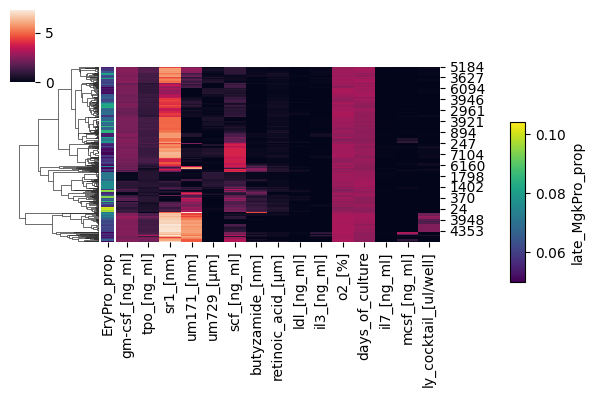

In [13]:
# Map the proportion values to colors using a continuous colormap
norm = Normalize(vmin=erypro_prop.min(), vmax=erypro_prop.max())
cmap = cm.viridis  # choose any colormap you like, e.g. "coolwarm", "magma"
row_colors = erypro_prop.map(lambda x: cmap(norm(x)))

g = sns.clustermap(
    erypro_prot,
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

# Add a separate colorbar legend for the row_colors annotation
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = g.fig.add_axes([1.02, 0.3, 0.03, 0.4])  # [left, bottom, width, height]
g.fig.colorbar(sm, cax=cbar_ax, label="late_MgkPro_prop")

plt.show()

In [14]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 5
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'EryPro_prop': erypro_prop.values
}, index=erypro_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['EryPro_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
3        0.073533   1774
4        0.072189     15
1        0.063963   4087
5        0.061559   1184
2        0.059010    147
      cluster  EryPro_prop
0           3     0.104108
1           3     0.103635
3           3     0.101093
6           3     0.100844
7           3     0.100715
...       ...          ...
6971        3     0.050772
7018        3     0.050520
7022        3     0.050501
7023        3     0.050493
7129        3     0.050283

[1774 rows x 2 columns]


Check if clusters are the ones we think

## Cluster 1

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


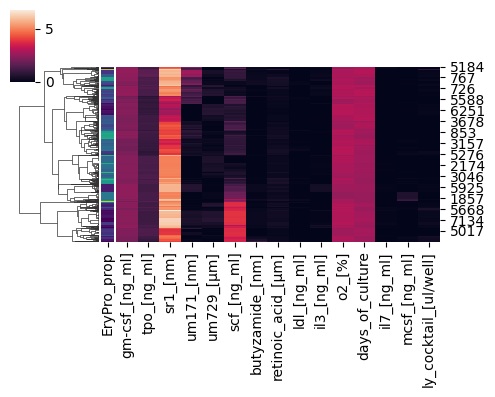

In [15]:
erypro_cl1 = erypro.loc[cluster_df[cluster_df.cluster==1].index]

sns.clustermap(
    np.log1p(erypro_cl1.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [16]:
erypro_cl1_select = erypro_cl1.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]
erypro_cl1_select

,index,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,EryPro_prop,filtering_step
2856,13,8.775424,2.687542,148.66779,0.0,0.530283,0.510789,0.000000,0.186199,0.000000,...,10.0,0.052675,0.000000,0.000000,14.340608,0.064481,1.656589,0.001493,0.067655,pass
2326,13,8.729982,2.489005,137.74196,0.0,0.540176,0.250683,0.000000,0.212100,0.000000,...,10.0,0.047610,0.000000,0.000000,14.313049,0.100931,1.779445,0.001415,0.069474,pass
5452,32,6.843951,2.219264,193.99094,0.0,0.142691,32.885666,0.205883,0.286009,0.051875,...,7.5,0.074986,0.118311,0.611091,13.694255,0.105716,2.306382,0.001623,0.057413,pass


## Cluster 2

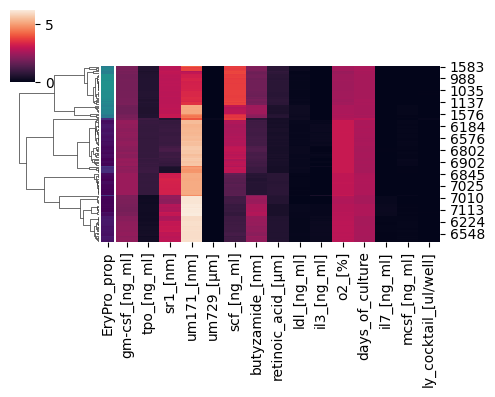

In [17]:
erypro_cl2 = erypro.loc[cluster_df[cluster_df.cluster==2].index]

sns.clustermap(
    np.log1p(erypro_cl2.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [18]:
erypro_cl2_select = erypro_cl2.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]
erypro_cl2_select

,index,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,EryPro_prop,filtering_step
6844,41,7.403602,1.360498,2.183228,270.91766,0.000136,17.715830,2.690129,0.482455,0.161119,...,15.0,0.028748,0.050200,0.000239,13.858871,0.150864,3.182280,0.001393,0.051449,pass
7141,41,8.976397,1.584888,1.567950,294.19858,0.000000,19.838179,2.225639,0.437159,0.166139,...,7.5,0.000000,0.070699,0.000000,13.896850,0.159969,3.322221,0.001207,0.050240,pass
1469,44,4.841619,0.704101,17.127562,172.65202,0.000000,16.710558,10.889884,0.622365,0.263105,...,7.5,0.000000,0.090948,0.000000,14.219263,0.165963,3.793668,0.001241,0.074402,pass


## Cluster 3

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


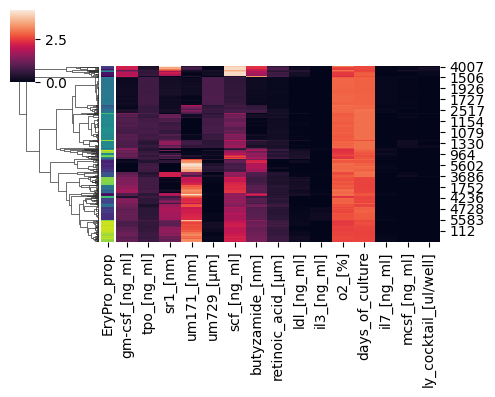

In [19]:
erypro_cl3 = erypro.loc[cluster_df[cluster_df.cluster==3].index]

sns.clustermap(
    np.log1p(erypro_cl3.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [20]:
erypro_cl3_select = erypro_cl3.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]
erypro_cl3_select

,index,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,EryPro_prop,filtering_step
4984,49,1.986580,0.566564,4.940161,7.102040,0.000000,5.248128,1.428938,0.545458,0.052579,...,10.0,0.000000,0.000000,0.000000,13.995337,0.089595,1.588307,0.001548,0.058849,pass
1440,40,1.811129,1.001855,0.895884,0.092388,0.152006,5.798370,4.036226,0.719653,0.339270,...,7.5,0.174975,0.028460,0.000000,13.810613,0.113914,1.432265,0.001796,0.074818,pass
1132,14,1.416626,0.825880,2.263990,0.582082,0.701237,4.150275,0.361146,0.442509,0.057897,...,15.0,0.004289,0.158034,0.137464,13.955701,0.119698,1.455442,0.001538,0.075871,pass


## Cluster 4

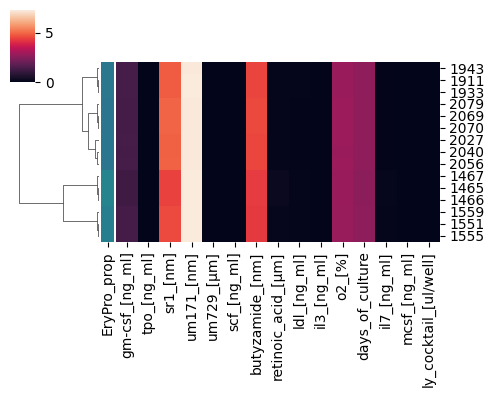

In [21]:
erypro_cl4 = erypro.loc[cluster_df[cluster_df.cluster==4].index]

sns.clustermap(
    np.log1p(erypro_cl4.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [22]:
erypro_cl4_select = erypro_cl4.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]
erypro_cl4_select

,index,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,EryPro_prop,filtering_step
2056,44,2.823907,0.0,128.72725,1398.9144,0.0,0.0,88.17545,0.069092,0.057127,...,1.0,0.052542,0.0,0.0,14.785380,0.234841,3.414437,0.001214,0.071131,pass
1555,44,2.737880,0.0,92.48048,1438.4860,0.0,0.0,71.79788,0.091433,0.074329,...,1.0,0.074172,0.0,0.0,14.649459,0.254107,3.593992,0.001349,0.072923,pass
1911,44,2.814913,0.0,120.35682,1408.3939,0.0,0.0,84.14657,0.073072,0.060162,...,1.0,0.054892,0.0,0.0,14.757656,0.270619,3.569022,0.001465,0.071449,pass


## Cluster 5

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


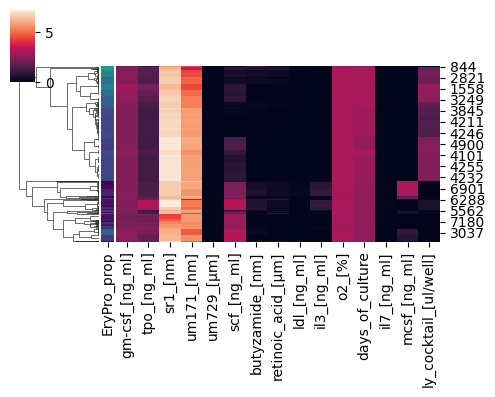

In [23]:
erypro_cl5 = erypro.loc[cluster_df[cluster_df.cluster==5].index]

sns.clustermap(
    np.log1p(erypro_cl5.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [24]:
erypro_cl5_select = erypro_cl5.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]
erypro_cl5_select

,index,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,EryPro_prop,filtering_step
6888,4,9.996080,3.010831,750.18475,373.98877,0.0,8.762938,0.453656,0.323843,0.095162,...,15.0,0.05788,20.262482,0.007459,14.509547,0.154325,3.219488,0.001185,0.051127,pass
6527,33,7.658797,7.202755,77.28603,296.58690,0.0,15.829643,0.000000,0.000000,0.005170,...,10.0,0.00000,0.000000,0.000000,14.015290,0.171676,3.132921,0.001206,0.052428,pass
3224,24,11.895929,8.128019,432.42145,111.92600,0.0,24.279284,0.136053,0.000000,0.000000,...,10.0,0.00000,1.636253,0.000000,13.738253,0.172123,2.714624,0.001455,0.065759,pass


## PCA with clusters

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


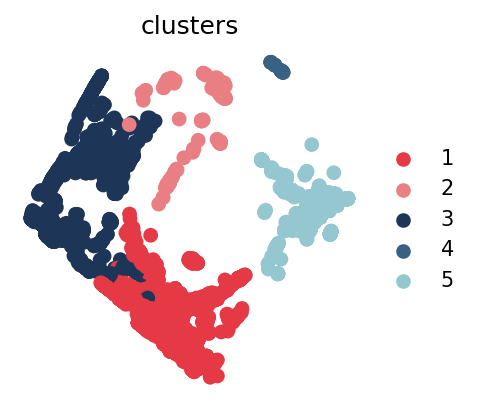

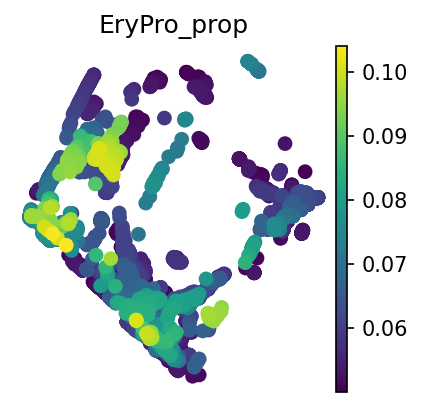

In [25]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = erypro_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=erypro)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")

    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        2: "#ea7f83",
        3: "#1D3557",
        4: "#376284",
        5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Option A: keep all points, give every category a color
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette)

    sc.pl.pca(
        adata_l4,
        s=200,
        color="clusters",
        frameon=False,
        groups=list(cluster_palette.keys()),
        palette=all_colors,
    )

    sc.pl.pca(adata_l4, s=200, color="EryPro_prop", frameon=False)

In [26]:
# erypro_cl1_select.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/erypro/cl1.csv")
# erypro_cl2_select.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/erypro/cl2.csv")
# erypro_cl3_select.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/erypro/cl3.csv")
# erypro_cl4_select.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/erypro/cl4.csv")
# erypro_cl5_select.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/erypro/cl5.csv")

# Plot and save clusters

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


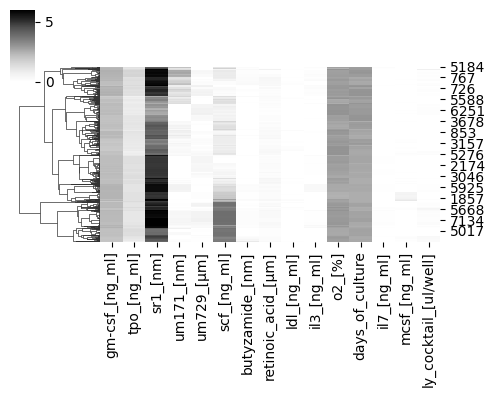

In [27]:
erypro_cl1 = erypro.loc[cluster_df[cluster_df.cluster==1].index]

g = sns.clustermap(
    np.log1p(erypro_cl1.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("erypro_cl1.png", dpi=300, bbox_inches="tight")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


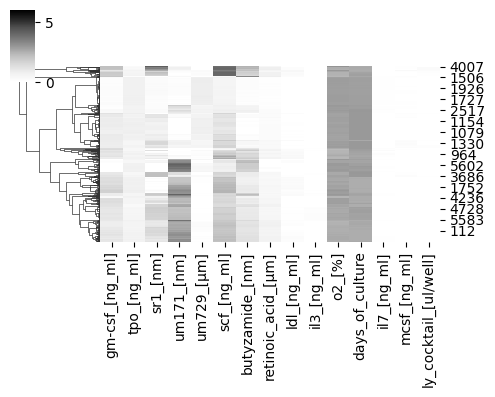

In [28]:
erypro_cl3 = erypro.loc[cluster_df[cluster_df.cluster==3].index]

g = sns.clustermap(
    np.log1p(erypro_cl3.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("erypro_cl3.png", dpi=300, bbox_inches="tight")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


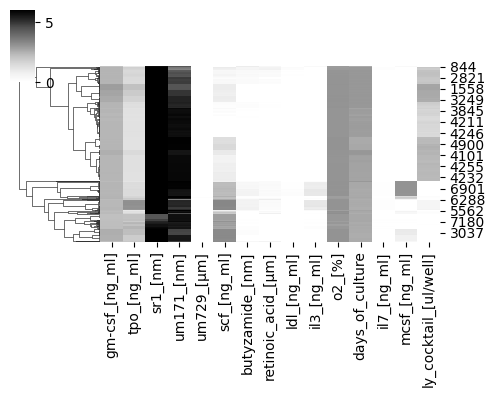

In [29]:
erypro_cl5 = erypro.loc[cluster_df[cluster_df.cluster==5].index]

g = sns.clustermap(
    np.log1p(erypro_cl5.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("erypro_cl5.png", dpi=300, bbox_inches="tight")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_556215/2047729103.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


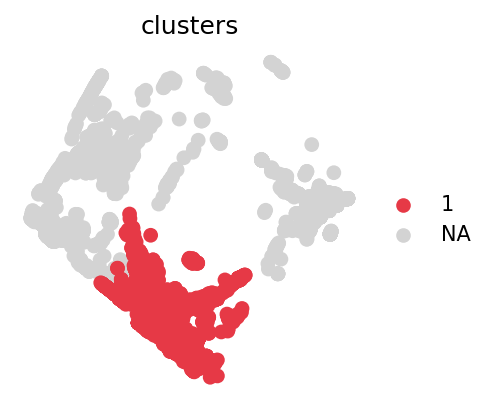

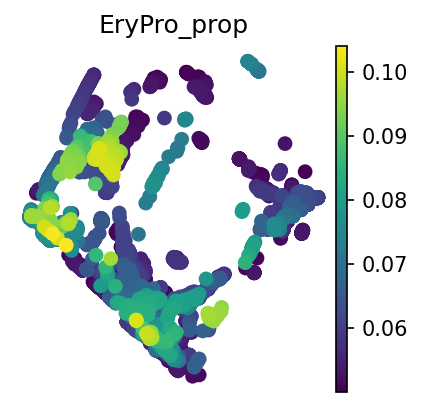

/tmp/ipykernel_556215/2047729103.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


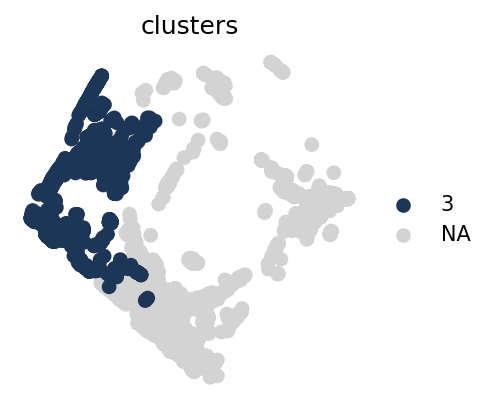

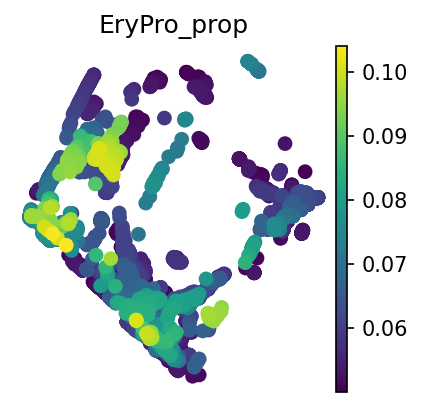

/tmp/ipykernel_556215/2047729103.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


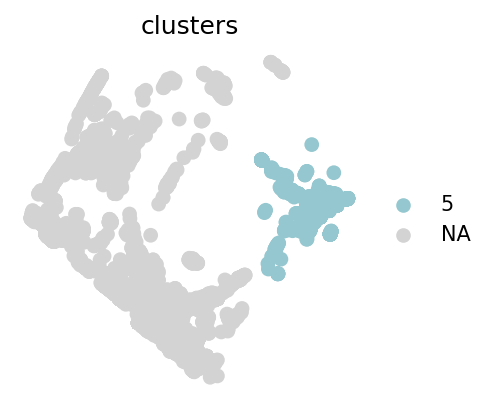

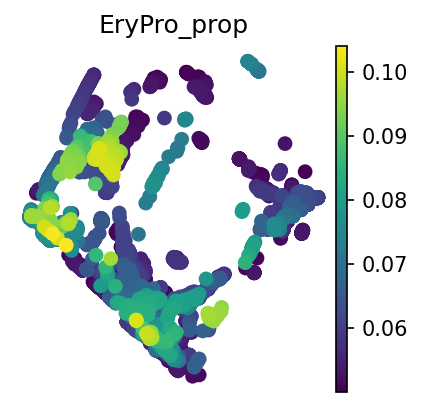

In [30]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = erypro_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=erypro)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")

    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        # 2: "#ea7f83",
        3: "#1D3557",
        # 4: "#376284",
        5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Option A: keep all points, give every category a color
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette)

    for cl in cluster_palette:
        sc.pl.pca(
            adata_l4,
            s=200,
            color="clusters",
            frameon=False,
            groups=[cl],
            palette=all_colors,
            save=f"erypro_prop_cl_{cl}.png"
        )
    
        sc.pl.pca(adata_l4, s=200, color="EryPro_prop", frameon=False)

In [31]:
adata_l4_log = adata_l4.copy()
adata_l4_log.obs["tpo_[ng_ml]"] = np.log1p(adata_l4_log.obs["tpo_[ng_ml]"])
sc.pp.log1p(adata_l4_log)

/tmp/ipykernel_556215/3367622480.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


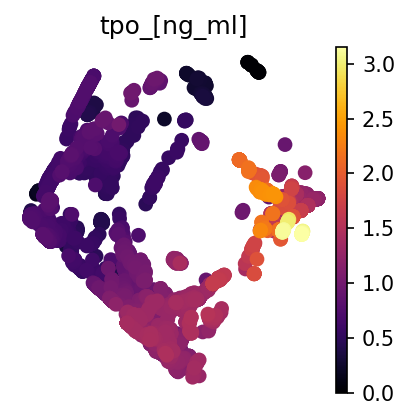

/tmp/ipykernel_556215/3367622480.py:12: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


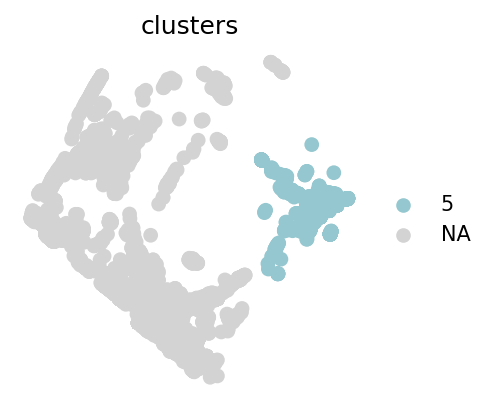

In [32]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    sc.pl.pca(
            adata_l4_log,
            s=200,
            color="tpo_[ng_ml]",
            frameon=False,
            palette=all_colors,
            cmap="inferno",
            save=f"erypro_gen_tpo_conc.png"
        )
    
    sc.pl.pca(
            adata_l4_log,
            s=200,
            color="clusters",
            frameon=False,
            palette=all_colors,
            groups=[5],
            save=f"erypro_prop_cl_5.png"
        )

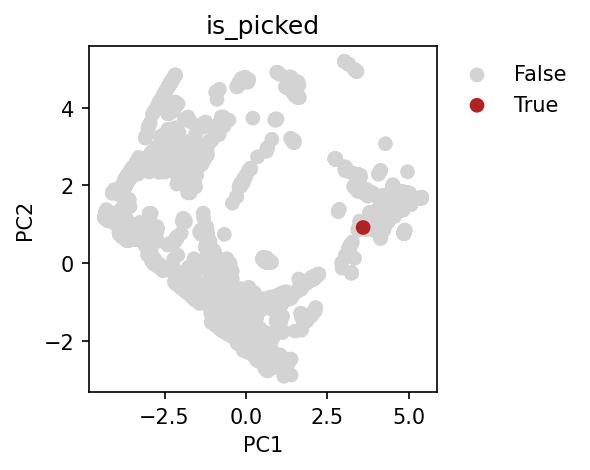

In [34]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    fig, ax = plt.subplots()
    coords = adata_l4_log.obsm["X_pca"][:, :2]
    # is_picked = (adata_l4.obs["tpo_[ng_ml]"].isin([8.131762, 1.5831759, 2.2214072])).values
    is_picked = (adata_l4.obs["tpo_[ng_ml]"].isin([8.131762])).values
    ax.scatter(coords[~is_picked, 0], coords[~is_picked, 1],
               s=50, color="lightgray", edgecolor="none", label="False")
    ax.scatter(coords[is_picked, 0], coords[is_picked, 1],
               s=50, color="firebrick", edgecolor="none", label="True")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("is_picked")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1))
    fig.savefig("pca_is_picked.png", dpi=300, bbox_inches="tight")